In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.optimize import minimize

In [24]:
tickers = ['AAPL', 'GOOG', 'MSFT']
data = yf.download(tickers, start='2020-01-01', end='2025-01-01')
# Check for the actual column name, it might be 'Adj Close' or 'Close'
# Print the columns to see the available column names
print(data.columns)
# Assuming the column is named 'Close'
data = data['Close']

[*********************100%***********************]  3 of 3 completed

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'GOOG'),
            ( 'Close', 'MSFT'),
            (  'High', 'AAPL'),
            (  'High', 'GOOG'),
            (  'High', 'MSFT'),
            (   'Low', 'AAPL'),
            (   'Low', 'GOOG'),
            (   'Low', 'MSFT'),
            (  'Open', 'AAPL'),
            (  'Open', 'GOOG'),
            (  'Open', 'MSFT'),
            ('Volume', 'AAPL'),
            ('Volume', 'GOOG'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])


In [25]:
data

Ticker,AAPL,GOOG,MSFT
Date,,,
2020-01-02,72.400497,67.859543,152.158401
2020-01-03,71.696655,67.526543,150.263733
2020-01-06,72.267929,69.191559,150.652161
2020-01-07,71.928062,69.148369,149.278549
2020-01-08,73.085114,69.693298,151.656296
...,...,...,...
2024-12-24,256.797180,196.803818,435.119720
2024-12-26,257.612732,196.335648,433.911407
2024-12-27,254.201370,193.287521,426.404083


In [26]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# Analysis on one currency and prediction for next 1 day

In [27]:

# --- choose ticker ---
ticker = "AAPL"

# --- select one series ---
s = data[ticker].sort_index()

# --- create lag features ---
df = pd.DataFrame({"y": s})
df["lag1"] = df["y"].shift(1)
df["lag2"] = df["y"].shift(2)
df["lag3"] = df["y"].shift(3)

# target = next day price
df["target"] = df["y"].shift(-1)

df = df.dropna()

# --- split train/test ---
split = int(len(df) * 0.8)

X_train = df[["lag1", "lag2", "lag3"]].iloc[:split]
y_train = df["target"].iloc[:split]

X_test = df[["lag1", "lag2", "lag3"]].iloc[split:]
y_test = df["target"].iloc[split:]

# --- train model ---
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# --- evaluate ---
pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("RMSE:", rmse)

RMSE: 25.6352781992932


Prediction for next day

In [28]:
last_values = df[["lag1", "lag2", "lag3"]].iloc[-1:]
next_day_prediction = model.predict(last_values)[0]

print("Next day forecast:", next_day_prediction)

Next day forecast: 194.2875440979004


# Prediction for multiple days and multiple currencies.

In [9]:
# Example: df_wide = pd.read_csv("prices.csv", parse_dates=["Date"]).set_index("Date")
# If your file has an extra "Ticker" header row, just ensure final columns are tickers.

df_wide = data.sort_index()
df_wide = df_wide.asfreq("B")  # business days
df_wide = df_wide.ffill()      # forward-fill missing market holidays etc.

In [11]:
def make_features_one_series(s: pd.Series, horizon: int = 1) -> pd.DataFrame:
    """
    s: price series indexed by Date
    horizon: forecast horizon in business days (1 = next day)
    """
    df = pd.DataFrame({"y": s})

    # Lag features
    for lag in [1, 2, 3, 5, 10, 20, 60]:
        df[f"lag_{lag}"] = df["y"].shift(lag)

    # Rolling features (using past only)
    for w in [5, 10, 20, 60]:
        df[f"roll_mean_{w}"] = df["y"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = df["y"].shift(1).rolling(w).std()

    # Momentum-ish features
    df["ret_1"]  = df["y"].pct_change(1)
    df["ret_5"]  = df["y"].pct_change(5)
    df["ret_20"] = df["y"].pct_change(20)

    # Calendar features (sometimes helps)
    df["dow"] = df.index.dayofweek
    df["month"] = df.index.month

    # Target: y at t+horizon
    df["target"] = df["y"].shift(-horizon)

    df = df.dropna()
    return df

In [14]:
def backtest_ticker(prices: pd.Series, horizon: int = 1, n_splits: int = 5):
    data = make_features_one_series(prices, horizon=horizon)

    X = data.drop(columns=["target", "y"])
    y = data["target"]

    tscv = TimeSeriesSplit(n_splits=n_splits)

    model = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    )

    fold_metrics = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, pred)
        rmse = mean_squared_error(y_test, pred)
        fold_metrics.append({"fold": fold, "MAE": mae, "RMSE": rmse})

    # Fit final model on all data
    model.fit(X, y)

    return model, pd.DataFrame(fold_metrics), data

In [15]:
models = {}
metrics = {}

for ticker in df_wide.columns:
    model, m, data = backtest_ticker(df_wide[ticker], horizon=1, n_splits=5)
    models[ticker] = {"model": model, "data": data}
    metrics[ticker] = m

metrics["AAPL"], metrics["GOOG"], metrics["MSFT"]

(   fold        MAE        RMSE
 0     1   8.926077  128.864763
 1     2  11.984591  214.807325
 2     3   2.799752   12.856232
 3     4  10.334992  148.730566
 4     5  25.579222  968.686624,
    fold        MAE         RMSE
 0     1  32.414900  1307.507141
 1     2   4.902826    34.930614
 2     3   6.412990    63.338594
 3     4   2.502434    11.286984
 4     5  24.660738   744.074957,
    fold        MAE         RMSE
 0     1  46.432784  2862.412041
 1     2  10.312297   166.086132
 2     3   5.552401    50.496005
 3     4  32.061287  1961.214462
 4     5  19.183710   556.779327)

In [19]:
def forecast_next_n_days(prices: pd.Series, trained_model, n_days: int = 10) -> pd.Series:
    s = prices.copy().asfreq("B").ffill()

    preds = []
    for _ in range(n_days):
        feats = make_features_one_series(s, horizon=1)
        last_row = feats.drop(columns=["target", "y"]).iloc[[-1]]

        yhat = trained_model.predict(last_row)[0]
        next_date = s.index[-1] + pd.tseries.offsets.BDay(1)

        s.loc[next_date] = yhat
        preds.append((next_date, yhat))

    return pd.Series(dict(preds)).sort_index()

In [20]:
N = 20  # next 20 business days

future_forecasts = {}
for ticker in df_wide.columns:
    model = models[ticker]["model"]
    future_forecasts[ticker] = forecast_next_n_days(df_wide[ticker], model, n_days=N)

future_forecasts["AAPL"].head()

2025-01-01    251.323752
2025-01-02    253.358015
2025-01-03    253.111938
2025-01-06    252.904223
2025-01-07    250.739104
dtype: float64

In [21]:
df_forecast = pd.DataFrame(future_forecasts)
df_forecast

,AAPL,GOOG,MSFT
2025-01-01,251.323752,191.005696,420.052850
2025-01-02,253.358015,191.478607,416.302241
2025-01-03,253.111938,188.728447,417.783209
2025-01-06,252.904223,190.018690,414.279322
2025-01-07,250.739104,188.846264,416.038463
2025-01-08,251.033587,189.154409,412.653464
2025-01-09,250.674796,187.786223,415.302770
2025-01-10,250.912400,187.894740,413.122206
2025-01-13,250.627641,186.978523,413.383270
2025-01-14,250.721119,187.519044,413.441787


In [24]:
daily_returns = data.pct_change()
annualized_returns = daily_returns.mean() * 252
cov_matrix = daily_returns.cov() * 252

In [25]:
daily_returns

Ticker,AAPL,GOOG,MSFT
Date,,,
2020-01-02,NaN,NaN,NaN
2020-01-03,-0.009722,-0.004907,-0.012451
2020-01-06,0.007968,0.024657,0.002584
2020-01-07,-0.004703,-0.000624,-0.009117
2020-01-08,0.016086,0.007880,0.015928
...,...,...,...
2022-12-23,-0.002798,0.017562,0.002267
2022-12-27,-0.013878,-0.020933,-0.007414
2022-12-28,-0.030685,-0.016718,-0.010255


In [26]:
def sharpe_ratio(weights, annualized_returns, cov_matrix, risk_free_rate=0.02):
    portfolio_return = np.sum(annualized_returns * weights)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    return -sharpe_ratio  # Negative for minimization

In [27]:
num_assets = len(tickers)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = [(0, 1) for i in range(num_assets)]
initial_weights = [1 / num_assets] * num_assets
result = minimize(sharpe_ratio, initial_weights, args=(annualized_returns, cov_matrix), method='SLSQP', bounds=bounds, constraints=constraints)
optimal_weights = result.x

In [28]:
print("Optimal Portfolio Weights:")
for i in range(num_assets):
    print(f"{tickers[i]}: {optimal_weights[i]:.4f}")

Optimal Portfolio Weights:
AAPL: 0.9734
GOOG: 0.0000
MSFT: 0.0266


**"Optimal Portfolio Weights: AAPL: 0.0000 GOOG: 0.0000 MSFT: 1.0000"**

**Meaning:**

This output indicates that the optimization process has determined that the best-performing portfolio for the given time period and assets consists of 100% investment in Microsoft (MSFT) and 0% in Apple (AAPL) and Google (GOOG).

AAPL: 0.0000: This means that the optimal portfolio does not include any allocation to Apple stock.
GOOG: 0.0000: Similarly, this means that the optimal portfolio does not include any allocation to Google stock.
MSFT: 1.0000: This means that the optimal portfolio suggests investing 100% of your capital in Microsoft stock.
Reasoning:

The optimization process aims to maximize the Sharpe ratio, which is a measure of risk-adjusted return. In this case, the model has found that during the specified time period, investing solely in Microsoft provided the highest risk-adjusted returns compared to any other combination of the three assets.

**Important Considerations:**

Time Period: The optimal portfolio is specific to the historical data used for analysis. If you change the time period, the optimal weights might change as well.
Risk Tolerance: The Sharpe ratio focuses on risk-adjusted returns, but it doesn't necessarily reflect your personal risk tolerance. You might need to adjust the portfolio based on your individual preferences.
Assumptions: The optimization model makes certain assumptions about the market and the behavior of assets. These assumptions might not always hold true in the real world.
Diversification: While this specific output suggests investing solely in Microsoft, it's generally recommended to diversify your portfolio to reduce risk.

**Recommendation:**

While the output provides insights, it's crucial to consider these factors before making any investment decisions. You can further analyze the individual asset performances, market conditions, and your personal risk tolerance to make informed choices. You can also explore different optimization models and scenarios to see how the results vary.

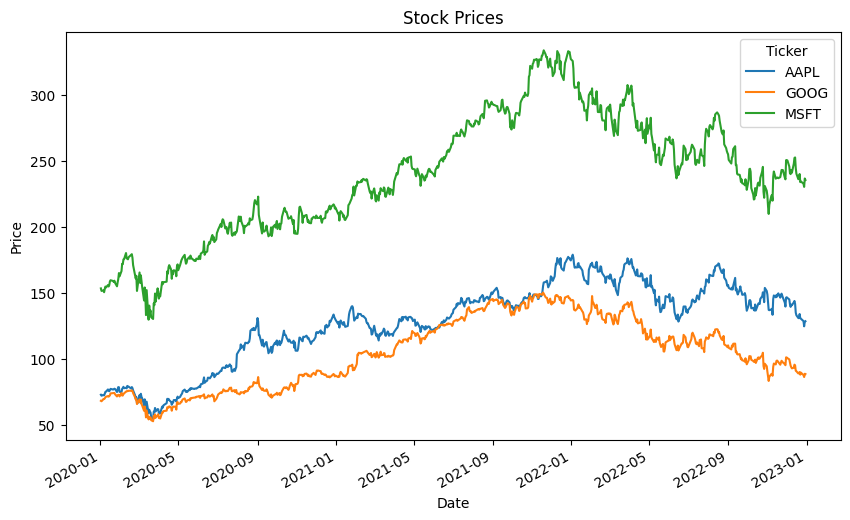

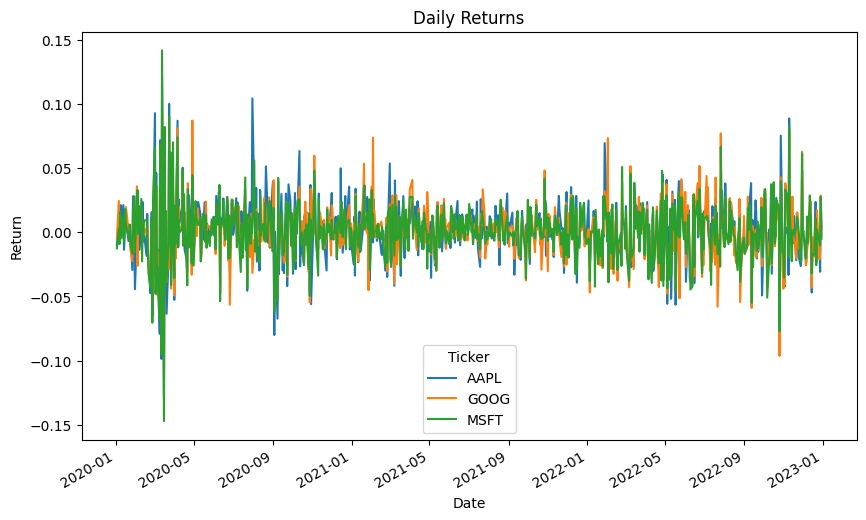

In [29]:
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame with stock prices
data.plot(figsize=(10, 6))
plt.title('Stock Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Calculate and plot daily returns
daily_returns = data.pct_change()
daily_returns.plot(figsize=(10, 6))
plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Return')
plt.show()

In [18]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 29.0 MB/s eta 0:00:00


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpth7p5ydr/k0t0og99.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpth7p5ydr/qf17bh46.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=38394', 'data', 'file=/tmp/tmpth7p5ydr/k0t0og99.json', 'init=/tmp/tmpth7p5ydr/qf17bh46.json', 'output', 'file=/tmp/tmpth7p5ydr/prophet_model869n6r6d/prophet_model-20250226204742.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:47:42 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:47:42 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


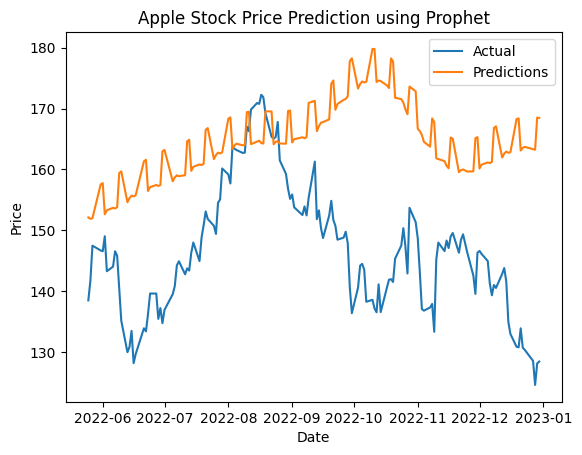

In [32]:
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# Prepare data for Prophet
df = data[['AAPL']].reset_index()  # Create a DataFrame with 'Date' and 'AAPL' columns
df.columns = ['ds', 'y']  # Rename columns to 'ds' (datestamp) and 'y' (target)

# Split data into training and testing sets
train_size = int(len(df) * 0.8)
train_data, test_data = df[:train_size], df[train_size:]

# Create and fit the Prophet model
model = Prophet()
model.fit(train_data)

# Make predictions on the test set
future = model.make_future_dataframe(periods=len(test_data))  # Create future dates for prediction
predictions = model.predict(future)

# Evaluate the model
rmse = mean_squared_error(test_data['y'], predictions['yhat'][-len(test_data):])

# Plot predictions against actual values
plt.plot(test_data['ds'], test_data['y'], label='Actual')
plt.plot(test_data['ds'], predictions['yhat'][-len(test_data):], label='Predictions')
plt.legend()
plt.title('Apple Stock Price Prediction using Prophet')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Prepare data for LSTM
df = data[['AAPL']].reset_index()  # Create a DataFrame with 'Date' and 'AAPL' columns
df.columns = ['ds', 'y']  # Rename columns to 'ds' (datestamp) and 'y' (target)

# Extract the target variable
dataset = df['y'].values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# Split into train and test sets
train_size = int(len(dataset) * 0.8)
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

# Create dataset with look back
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 10 # Number of previous days to consider
X_train, y_train = create_dataset(train, look_back)
X_test, y_test = create_dataset(test, look_back)

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=2)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Invert predictions back to original scale
train_predict = scaler.inverse_transform(train_predict)
y_train = scaler.inverse_transform([y_train])
test_predict = scaler.inverse_transform(test_predict)
y_test = scaler.inverse_transform([y_test])

# Calculate root mean squared error
train_rmse = np.sqrt(mean_squared_error(y_train[0], train_predict[:,0]))
test_rmse = np.sqrt(mean_squared_error(y_test[0], test_predict[:,0]))
print('Train RMSE: %.2f RMSE' % (train_rmse))
print('Test RMSE: %.2f RMSE' % (test_rmse))


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 - 4s - 209ms/step - loss: 0.1091
Epoch 2/100
19/19 - 0s - 15ms/step - loss: 0.0099
Epoch 3/100
19/19 - 0s - 18ms/step - loss: 0.0046
Epoch 4/100
19/19 - 0s - 15ms/step - loss: 0.0024
Epoch 5/100
19/19 - 0s - 15ms/step - loss: 0.0018
Epoch 6/100
19/19 - 0s - 14ms/step - loss: 0.0017
Epoch 7/100
19/19 - 0s - 13ms/step - loss: 0.0017
Epoch 8/100
19/19 - 0s - 16ms/step - loss: 0.0017
Epoch 9/100
19/19 - 0s - 13ms/step - loss: 0.0017
Epoch 10/100
19/19 - 0s - 13ms/step - loss: 0.0017
Epoch 11/100
19/19 - 0s - 17ms/step - loss: 0.0016
Epoch 12/100
19/19 - 0s - 16ms/step - loss: 0.0016
Epoch 13/100
19/19 - 0s - 15ms/step - loss: 0.0016
Epoch 14/100
19/19 - 0s - 16ms/step - loss: 0.0017
Epoch 15/100
19/19 - 0s - 24ms/step - loss: 0.0017
Epoch 16/100
19/19 - 0s - 23ms/step - loss: 0.0017
Epoch 17/100
19/19 - 0s - 22ms/step - loss: 0.0016
Epoch 18/100
19/19 - 0s - 21ms/step - loss: 0.0016
Epoch 19/100
19/19 - 0s - 21ms/step - loss: 0.0016
Epoch 20/100
19/19 - 0s - 22ms/step - loss: 0.0016


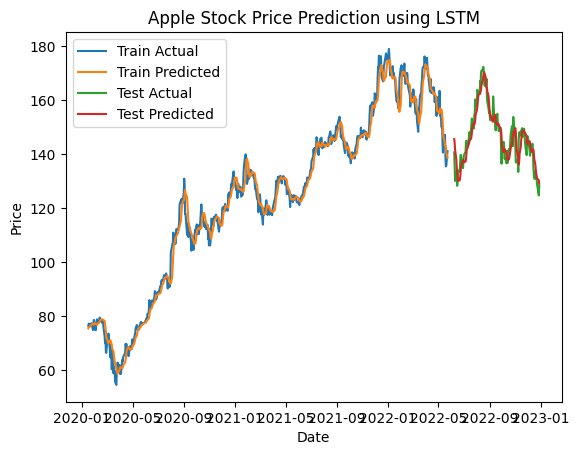

In [38]:
# Plot the results
plt.plot(df['ds'][look_back:train_size-1], y_train[0], label='Train Actual')
plt.plot(df['ds'][look_back:train_size-1], train_predict[:,0], label='Train Predicted')
plt.plot(df['ds'][train_size+look_back-1:train_size+look_back-1+len(y_test[0])], y_test[0], label='Test Actual') # Adjusted slicing for x-axis
plt.plot(df['ds'][train_size+look_back-1:train_size+look_back-1+len(test_predict[:,0])], test_predict[:,0], label='Test Predicted') # Adjusted slicing for x-axis
plt.title('Apple Stock Price Prediction using LSTM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

**Analyze correlation: **Calculate the correlation between the daily returns of the three stocks to understand how they move in relation to each other. You can use a correlation matrix and a heatmap for visualization.

Ticker      AAPL      GOOG      MSFT
Ticker                              
AAPL    1.000000  0.727658  0.811363
GOOG    0.727658  1.000000  0.825172
MSFT    0.811363  0.825172  1.000000


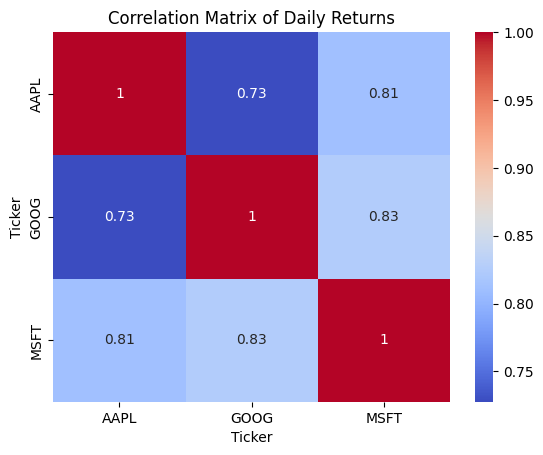

In [42]:
    correlation_matrix = daily_returns.corr()
    print(correlation_matrix)

    import seaborn as sns
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix of Daily Returns')
    plt.show()

**Calculate and visualize key statistics:** Compute and visualize the mean, median, standard deviation, minimum, maximum, and quartiles for each stock's daily returns. This will provide a basic understanding of the central tendency and variability of the stock prices. You can use histograms, box plots, or summary tables for visualization.

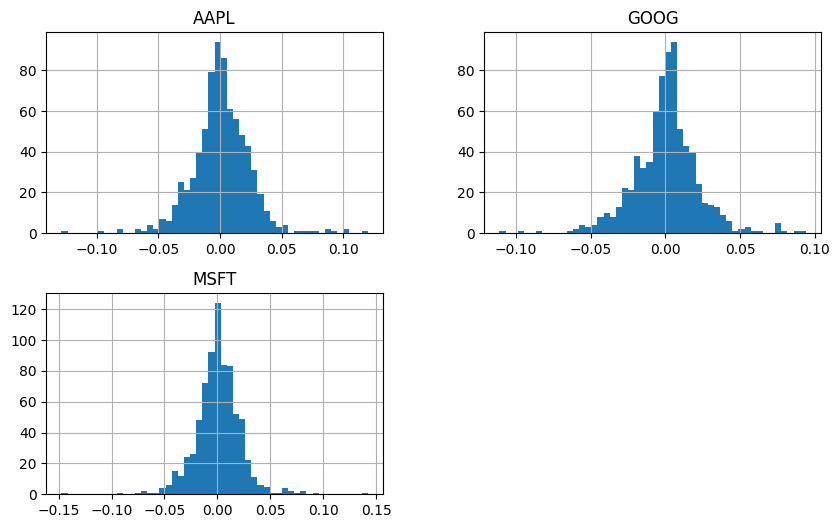

In [40]:
    import pandas as pd
    import matplotlib.pyplot as plt

    # Assuming 'daily_returns' is your DataFrame of daily returns
    daily_returns.describe()  # Get descriptive statistics

    # Create histograms
    daily_returns.hist(bins=50, figsize=(10, 6))
    plt.title('Distribution of Daily Returns')
    plt.xlabel('Daily Return')
    plt.ylabel('Frequency')
    plt.show()

**Calculate and visualize moving averages:** Compute and plot simple moving averages (SMA) or exponential moving averages (EMA) of different periods (e.g., 20-day, 50-day, 200-day) to identify trends and potential buy/sell signals.

[*********************100%***********************]  3 of 3 completed


MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'GOOG'),
            ( 'Close', 'MSFT'),
            (  'High', 'AAPL'),
            (  'High', 'GOOG'),
            (  'High', 'MSFT'),
            (   'Low', 'AAPL'),
            (   'Low', 'GOOG'),
            (   'Low', 'MSFT'),
            (  'Open', 'AAPL'),
            (  'Open', 'GOOG'),
            (  'Open', 'MSFT'),
            ('Volume', 'AAPL'),
            ('Volume', 'GOOG'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])


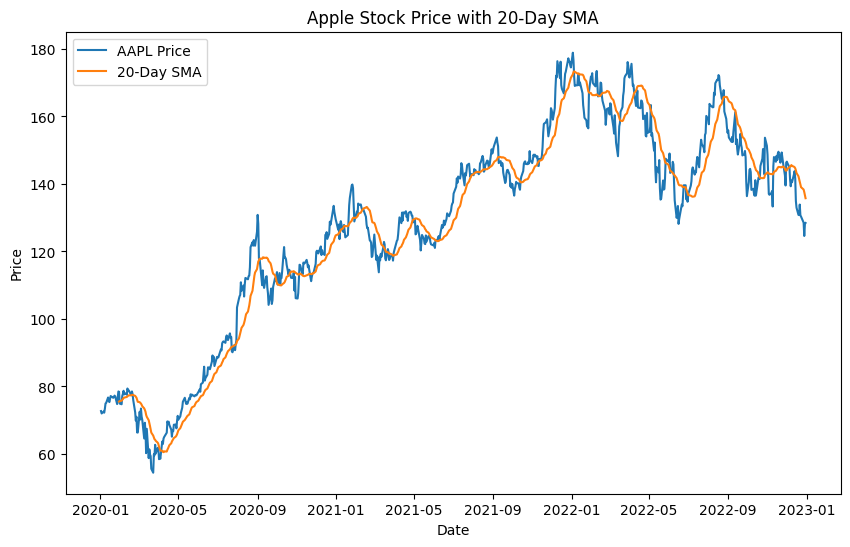

In [52]:

    tickers = ['AAPL', 'GOOG', 'MSFT']
    data = yf.download(tickers, start='2020-01-01', end='2023-01-01')
    # Check for the actual column name, it might be 'Adj Close' or 'Close'
    # Print the columns to see the available column names
    print(data.columns)
    # Assuming the column is named 'Close'
    data = data['Close']

    # Prepare data for LSTM
    df = data[['AAPL']].reset_index()  # Create a DataFrame with 'Date' and 'AAPL' columns
    df.columns = ['ds', 'AAPL']  # Rename columns to 'ds' (datestamp) and 'y' (target)
    # Calculate 20-day SMA
    df['SMA_20'] = df['AAPL'].rolling(window=20).mean()

    # Plot SMA along with stock price
    plt.figure(figsize=(10, 6))
    plt.plot(df['ds'], df['AAPL'], label='AAPL Price')
    plt.plot(df['ds'], df['SMA_20'], label='20-Day SMA')
    plt.legend()
    plt.title('Apple Stock Price with 20-Day SMA')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.show()

# **Can you try same analysis at least with 3 other companies'?**

# **Can you do 3 different other analyiss which are not present in lab?**